In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import median_abs_deviation
import numpy as np
import os
import re
from pathlib import Path
from anndata.experimental import concat_on_disk
import gc


In [2]:
# # Read files in batches and concatenate incrementally using backed mode

# dir = Path("/rds/general/user/ztb25/home/PBMC_datasets/6/GSE275067_RAW/")
# all_files = sorted(dir.glob("*.h5"))[:100]  # Stop at 100 files
# print(f"Total files to process: {len(all_files)}")

# # Create output zarr store (more efficient than h5ad for incremental writes)
# output_zarr = "dataset6_combined.zarr"
# adata = None

# for file_idx, file in enumerate(all_files, 1):
#     sample_name = file.stem
#     print(f"\nProcessing file {file_idx}/{len(all_files)}: {sample_name}")
    
#     try:
#         a = sc.read_10x_h5(file)
#         a.var_names_make_unique()
#         a.obs["sample"] = sample_name
        
#         if adata is None:
#             # Initialize with first file
#             adata = a
#             print(f"  Initialized with shape {adata.shape}")
#         else:
#             # Concatenate and save to zarr to free memory
#             adata = ad.concat([adata, a], axis=0, join='outer')
#             adata.obs_names_make_unique()
            
#             # Every 10 files, write to zarr and reload to free memory
#             if file_idx % 10 == 0:
#                 print(f"  Checkpoint at {file_idx} files: writing to zarr...")
#                 adata.write_zarr(output_zarr, mode='w')
#                 del adata
#                 gc.collect()
#                 adata = ad.read_zarr(output_zarr)
#                 print(f"  Current shape: {adata.shape}")
#             else:
#                 print(f"  Current shape: {adata.shape}")
                
#     except Exception as e:
#         print(f"  Error: {e}")
#         gc.collect()
#         continue

# # Final write
# print(f"\nFinal write to zarr...")
# adata.write_zarr(output_zarr, mode='w')
# print(f"Final shape: {adata.shape}")
# print("✓ Data saved to zarr and loaded into adata object")

In [3]:
# # Extract and create GSM id column in obs
# adata.obs["GSM_id"] = adata.obs["sample"].str.extract(r"(GSM\d+)")
# display(adata.obs["GSM_id"].nunique())
# adata.obs

In [4]:
# # inspect matrix (check whole numbers)
# pd.DataFrame(
#     adata.X[:10, :20].toarray(),
#     index=adata.obs_names[:10],
#     columns=adata.var_names[:20]
# )

In [5]:
# read in and inspect metadata text file

file_path = "/rds/general/user/ztb25/home/PBMC_datasets/6/GSE275067.txt"

with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
    text = f.read()


idx = text.find("^SAMPLE =")
print(text[idx:idx+2000])

^SAMPLE = GSM8464886
!Sample_title = PB03173-001 flex scRNA-seq
!Sample_geo_accession = GSM8464886
!Sample_status = Public on Sep 12 2025
!Sample_submission_date = Aug 16 2024
!Sample_last_update_date = Sep 12 2025
!Sample_type = SRA
!Sample_channel_count = 1
!Sample_source_name_ch1 = Blood
!Sample_organism_ch1 = Homo sapiens
!Sample_taxid_ch1 = 9606
!Sample_characteristics_ch1 = tissue: Blood
!Sample_characteristics_ch1 = cell type: PBMC
!Sample_characteristics_ch1 = subject id: SF3001
!Sample_characteristics_ch1 = age at_enrollment: 52
!Sample_characteristics_ch1 = Sex: Female
!Sample_characteristics_ch1 = race: African American
!Sample_characteristics_ch1 = cmv status: Negative
!Sample_characteristics_ch1 = batch id: B172
!Sample_characteristics_ch1 = sample bridging_control: FALSE
!Sample_characteristics_ch1 = pooled sample_id: B172-PC
!Sample_characteristics_ch1 = probe barcode_id: BC010
!Sample_molecule_ch1 = other
!Sample_extract_protocol_ch1 = PBMCs were removed from liquid nit

In [6]:
# turn metadata text file into dataframt to merge with adata.obs, extracting age, sex, race, batch, and subject ID (SF_id)

dir_meta = "/rds/general/user/ztb25/home/PBMC_datasets/6/GSE275067.txt"
records = []
current = None

with open(dir_meta, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        line = line.rstrip("\n")

        if line.startswith("^SAMPLE = "):
            if current is not None:
                records.append(current)
            current = {"GSM_id": line.split(" = ", 1)[1]}

        elif current is not None:
            if line.startswith("!Sample_title = "):
                current["sample_title"] = line.split(" = ", 1)[1]

            elif line.startswith("!Sample_characteristics_ch1 = "):
                val = line.split(" = ", 1)[1]

                if val.startswith("subject id:"):
                    current["SF_id"] = val.split(":", 1)[1].strip()
                elif val.startswith("age at_enrollment:"):
                    current["age"] = val.split(":", 1)[1].strip()
                elif val.startswith("Sex:"):
                    current["gender"] = val.split(":", 1)[1].strip()
                elif val.startswith("race:"):
                    current["race"] = val.split(":", 1)[1].strip()
                elif val.startswith("batch id:"):
                    current["batch"] = val.split(":", 1)[1].strip()

    if current is not None:
        records.append(current)

geo_meta = pd.DataFrame(records)

geo_meta = geo_meta[["GSM_id", "SF_id", "age", "gender", "race", "batch"]].drop_duplicates()
geo_meta.head()

,GSM_id,SF_id,age,gender,race,batch
0,GSM8464886,SF3001,52,Female,African American,B172
1,GSM8464887,SF3006,68,Male,American Indian,B172
2,GSM8464888,SF3016,47,Male,Caucasian,B171
3,GSM8464889,SF3020,70,Female,Asian,B155
4,GSM8464890,SF3024,50,Female,American Indian,B172


In [7]:
# add age bin column to geo_meta

bins = [39, 49, 59, 69, 79, 200]
labels = ["40-50", "50-59", "60-69", "70-79", "80+"]

geo_meta["age"] = pd.to_numeric(geo_meta["age"], errors="coerce")

geo_meta["age_bin"] = pd.cut(
    geo_meta["age"],
    bins=bins,
    labels=labels,
    right=True
)

geo_meta

,GSM_id,SF_id,age,gender,race,batch,age_bin
0,GSM8464886,SF3001,52.0,Female,African American,B172,50-59
1,GSM8464887,SF3006,68.0,Male,American Indian,B172,60-69
2,GSM8464888,SF3016,47.0,Male,Caucasian,B171,40-50
3,GSM8464889,SF3020,70.0,Female,Asian,B155,70-79
4,GSM8464890,SF3024,50.0,Female,American Indian,B172,50-59
...,...,...,...,...,...,...,...
247,GSM8465133,na,NaN,pooled male and female,na,B172,NaN
248,GSM8465134,na,NaN,pooled male and female,na,B172,NaN
249,GSM8465135,na,NaN,pooled male and female,na,B173,NaN
250,GSM8465136,na,NaN,pooled male and female,na,B173,NaN


In [8]:
# # subset metadata to only samples in adata

# adata_gsm_ids = adata.obs["GSM_id"].unique()
# geo_meta = geo_meta[geo_meta["GSM_id"].isin(adata_gsm_ids)]
# print(geo_meta.shape)

In [9]:
# # merge age and metadata with adata.obs on donor_id (for only the 50 samples we have)
# adata.obs = adata.obs.merge(geo_meta, on='GSM_id', how='left')
# adata.obs.head()

In [10]:
# # calculate sample counts and proportions of samples in age bands (50-59, 60-69, 70-79, 80+), for age-matching with PD dataset

# # extract from obs, one row per sample with age and diagnosis
# sample_ages = adata.obs[["GSM_id", "age"]].drop_duplicates().copy()
# sample_ages["age"] = pd.to_numeric(sample_ages["age"], errors="coerce")

# bins = [39, 49, 59, 69, 79, 200]
# labels = ["40-50", "50-59", "60-69", "70-79", "80+"]

# sample_ages["age_band"] = pd.cut(sample_ages["age"], bins=bins, labels=labels, right=True, include_lowest=True)

# # overall counts and proportions of samples per age band
# control_counts = sample_ages["age_band"].value_counts().reindex(labels, fill_value=0)
# age_band_props = (control_counts / control_counts.sum()).round(3)
# control_counts = pd.DataFrame({"count": control_counts, "proportion": age_band_props})

# display(control_counts)

In [11]:
# get target age bin counts: import all tables of count by age band and diagnosis from other datasets

d1 = pd.read_csv("/rds/general/user/ztb25/home/PBMC_datasets/1/age_band_props_by_diagnosis.csv", index_col=0)
d2 = pd.read_csv("/rds/general/user/ztb25/home/PBMC_datasets/4/age_band_props_by_diagnosis.csv", index_col=0)
d3 = pd.read_csv("/rds/general/user/ztb25/home/PBMC_datasets/5/age_band_props_by_diagnosis.csv", index_col=0)

In [12]:
# using the tables, calculate the total number of samples in the PD and AD diagnosis subgroups (disease) in all samples

d1["dataset"] = "dataset1"
d2["dataset"] = "dataset4"
d3["dataset"] = "dataset5"
disease_counts = pd.concat([d1, d2, d3], ignore_index=False)

# take only the PD or AD rows (from the index)
disease_counts = disease_counts.loc[disease_counts.index.isin(["PD", "AD"])]


# create a total row (for all but the dataset column)
disease_counts.loc["Total"] = disease_counts.drop(columns=["dataset"]).sum()
display(disease_counts)

# get and overall total sum of disease samples
total_samples = disease_counts.loc["Total"].sum()
display(total_samples)


,40-50,50-59,60-69,70-79,80+,dataset
diagnosis,,,,,,
PD,0.0,0.0,2.0,2.0,0.0,dataset1
AD,1.0,2.0,8.0,9.0,8.0,dataset4
PD,0.0,0.0,10.0,4.0,0.0,dataset5
Total,1.0,2.0,20.0,15.0,8.0,NaN


46.0

In [13]:
# # create a target age band counts for the control samples (from the total row of the total_samples, halfing to save memory)

# target_counts = {
#     "40-50": 0,
#     "50-59": 1,
#     "60-69": 10,
#     "70-79": 8,
#     "80+": 4
# }

# np.random.seed(42)

# # subset geo_meta to target age band counts, randomly sampling from each age band if there are more samples than the target count for that band, and taking all samples if there are fewer than the target count for that band

# selected_rows = []

# for age_bin, target_n in target_counts.items():
#     pool = geo_meta[geo_meta["age_bin"] == age_bin].copy()
    
#     n_keep = min(target_n, len(pool))
    
#     if n_keep > 0:
#         sampled = pool.sample(n=n_keep, replace=False, random_state=42)
#         selected_rows.append(sampled)

# geo_meta_subset = pd.concat(selected_rows, ignore_index=True)
# geo_meta_subset


In [14]:
target_age = {
    "40-50": 0,
    "50-59": 1,
    "60-69": 10,
    "70-79": 8,
    "80+": 4
}

# Ratios derived from your disease sample demographics
sex_ratio    = {"Female": 25/46, "Male": 21/46}
eth_ratio    = {"Caucasian": 40/46, "Asian": 6/46}


def allocate_cells(n, sex_ratio, eth_ratio):
    """Proportionally split n across (sex, ethnicity) cells.
    Uses largest-remainder rounding to preserve the total exactly."""
    cells = {
        (sex, eth): n * sr * er
        for sex, sr in sex_ratio.items()
        for eth, er in eth_ratio.items()
    }
    floored   = {k: int(v) for k, v in cells.items()}
    remainders = {k: cells[k] - floored[k] for k in cells}
    deficit   = n - sum(floored.values())

    # Award leftover slots to cells with largest remainders
    for k in sorted(remainders, key=remainders.get, reverse=True)[:deficit]:
        floored[k] += 1

    return floored


np.random.seed(42)
selected_rows = []

for age_bin, age_n in target_age.items():
    if age_n == 0:
        continue

    cell_targets = allocate_cells(age_n, sex_ratio, eth_ratio)

    for (sex, eth), n_target in cell_targets.items():
        if n_target == 0:
            continue

        pool = geo_meta[
            (geo_meta["age_bin"]   == age_bin) &
            (geo_meta["gender"]       == sex) &
            (geo_meta["race"] == eth)
        ].copy()

        n_keep = min(n_target, len(pool))  # graceful if pool is too small
        if n_keep > 0:
            sampled = pool.sample(n=n_keep, replace=False, random_state=42)
            selected_rows.append(sampled)

geo_meta_subset = pd.concat(selected_rows, ignore_index=True)

# Quick sanity check
print(geo_meta_subset.groupby(["age_bin", "gender", "race"]).size().to_string())
print(f"\nTotal: {len(geo_meta_subset)}")
print(geo_meta_subset["gender"].value_counts().to_string())
print(geo_meta_subset["race"].value_counts().to_string())

age_bin  gender  race     
40-50    Female  Asian        0
                 Caucasian    0
         Male    Asian        0
                 Caucasian    0
50-59    Female  Asian        0
                 Caucasian    1
         Male    Asian        0
                 Caucasian    0
60-69    Female  Asian        1
                 Caucasian    5
         Male    Asian        0
                 Caucasian    4
70-79    Female  Asian        1
                 Caucasian    4
         Male    Asian        0
                 Caucasian    3
80+      Female  Asian        0
                 Caucasian    2
         Male    Asian        0
                 Caucasian    2

Total: 23
Female    14
Male       9
Caucasian    21
Asian         2


In [15]:
# read in files with the selected GSM ids

# GSMs you want
selected_gsms = set(geo_meta_subset["GSM_id"].dropna().unique())

# folder with h5 files
dir = Path("/rds/general/user/ztb25/home/PBMC_datasets/6/GSE275067_RAW/")

# all h5 files
all_files = sorted(dir.glob("*.h5"))

# keep only files whose name starts with one of the selected GSM IDs
files_to_read = [f for f in all_files if f.name.split("_")[0] in selected_gsms]

display(len(files_to_read))
display(files_to_read[:5])

23

[PosixPath('/rds/general/user/ztb25/home/PBMC_datasets/6/GSE275067_RAW/GSM8464889_fRNA_B155_PB03199-003_labeled.h5'),
 PosixPath('/rds/general/user/ztb25/home/PBMC_datasets/6/GSE275067_RAW/GSM8464908_fRNA_B173_PB03287-001_labeled.h5'),
 PosixPath('/rds/general/user/ztb25/home/PBMC_datasets/6/GSE275067_RAW/GSM8464910_fRNA_B151_PB03292-001_labeled.h5'),
 PosixPath('/rds/general/user/ztb25/home/PBMC_datasets/6/GSE275067_RAW/GSM8464911_fRNA_B172_PB03297-001_labeled.h5'),
 PosixPath('/rds/general/user/ztb25/home/PBMC_datasets/6/GSE275067_RAW/GSM8464912_fRNA_B172_PB03303-001_labeled.h5')]

In [16]:
meta_lookup = geo_meta_subset.set_index("GSM_id")

adatas = []

for file in files_to_read:
    gsm = file.name.split("_")[0]
    
    a = sc.read_10x_h5(file)
    a.var_names_make_unique()
    
    a.obs["sample"] = file.stem
    a.obs["GSM_id"] = gsm
    
    a.obs["age"] = meta_lookup.loc[gsm, "age"]
    a.obs["gender"] = meta_lookup.loc[gsm, "gender"]
    a.obs["race"] = meta_lookup.loc[gsm, "race"]
    a.obs["age_bin"] = meta_lookup.loc[gsm, "age_bin"]
    a.obs["batch"] = meta_lookup.loc[gsm, "batch"]
    
    adatas.append(a)

/rds/general/user/ztb25/home/miniforge3/envs/m10/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


/rds/general/user/ztb25/home/miniforge3/envs/m10/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


/rds/general/user/ztb25/home/miniforge3/envs/m10/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


/rds/general/user/ztb25/home/miniforge3/envs/m10/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


/rds/general/user/ztb25/home/miniforge3/envs/m10/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


...

/rds/general/user/ztb25/home/miniforge3/envs/m10/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


/rds/general/user/ztb25/home/miniforge3/envs/m10/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


/rds/general/user/ztb25/home/miniforge3/envs/m10/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


/rds/general/user/ztb25/home/miniforge3/envs/m10/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


/rds/general/user/ztb25/home/miniforge3/envs/m10/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [17]:
adata = sc.concat(adatas, join="outer", index_unique="-")

In [18]:
adata

AnnData object with n_obs × n_vars = 567837 × 18082
    obs: 'sample', 'GSM_id', 'age', 'gender', 'race', 'age_bin', 'batch'

In [19]:
display(adata.obs.head())
display(adata.var.head()) 

,sample,GSM_id,age,gender,race,age_bin,batch
7114b88eb05111ee829342154c21cb59-0,GSM8464889_fRNA_B155_PB03199-003_labeled,GSM8464889,70.0,Female,Asian,70-79,B155
7114b942b05111ee829342154c21cb59-0,GSM8464889_fRNA_B155_PB03199-003_labeled,GSM8464889,70.0,Female,Asian,70-79,B155
7114b9c4b05111ee829342154c21cb59-0,GSM8464889_fRNA_B155_PB03199-003_labeled,GSM8464889,70.0,Female,Asian,70-79,B155
7114ba3cb05111ee829342154c21cb59-0,GSM8464889_fRNA_B155_PB03199-003_labeled,GSM8464889,70.0,Female,Asian,70-79,B155
7114bab4b05111ee829342154c21cb59-0,GSM8464889_fRNA_B155_PB03199-003_labeled,GSM8464889,70.0,Female,Asian,70-79,B155


""
SAMD11
NOC2L
KLHL17
PLEKHN1
PERM1


In [20]:
# check adata matric (to check if whole numbers)
pd.DataFrame(
    adata.X[:10, :20].toarray(),
    index=adata.obs_names[:10],
    columns=adata.var_names[:20]
)

,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,RNF223,C1orf159,TTLL10,TNFRSF18,TNFRSF4,SDF4,B3GALT6,C1QTNF12,UBE2J2,SCNN1D,ACAP3,PUSL1
7114b88eb05111ee829342154c21cb59-0,0,3,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0
7114b942b05111ee829342154c21cb59-0,0,2,0,0,0,1,1,0,0,0,0,2,0,7,0,0,0,0,3,0
7114b9c4b05111ee829342154c21cb59-0,0,0,0,0,0,0,1,0,0,0,0,0,0,2,0,1,0,0,0,0
7114ba3cb05111ee829342154c21cb59-0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0
7114bab4b05111ee829342154c21cb59-0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7114bb22b05111ee829342154c21cb59-0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0
7114bb9ab05111ee829342154c21cb59-0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,2,0,0,0,0,0
7114bc12b05111ee829342154c21cb59-0,0,0,2,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0
7114bc80b05111ee829342154c21cb59-0,0,2,2,0,0,0,1,1,0,0,0,0,0,3,0,0,0,2,0,0
7114bcf8b05111ee829342154c21cb59-0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


In [21]:
# Run QC globally

# Annotate mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")  

sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"], 
    percent_top=[20],
    log1p=True,
    inplace=True
)

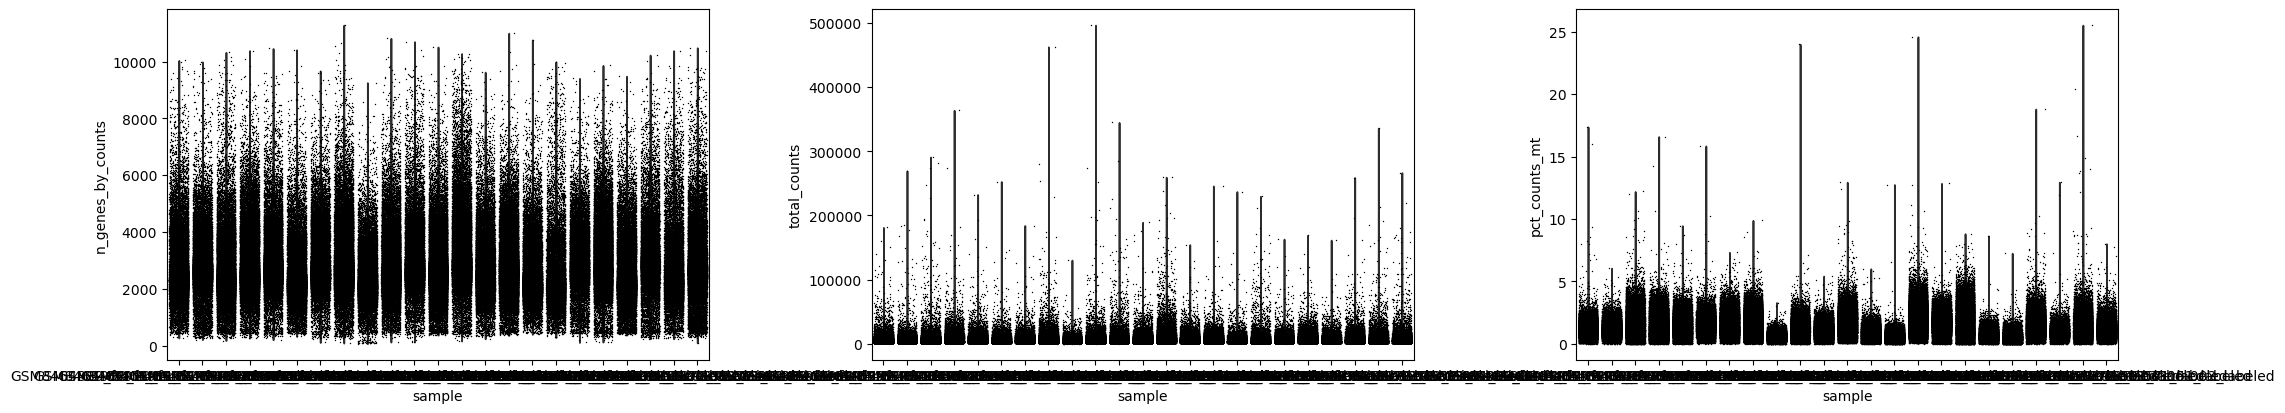

In [22]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    groupby="sample",
    jitter=0.4,
    multi_panel=True
)

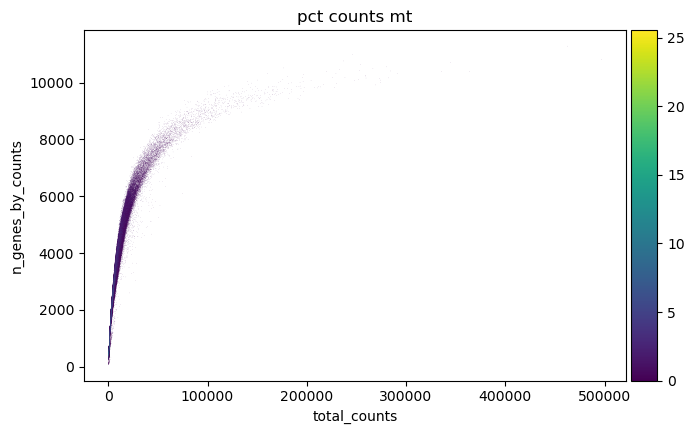

In [23]:
p1 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [24]:
# group by sample (to avoid skewing from bad samples) and flag outliers based on median absolute deviation (MAD).
def is_outlier_per_sample(adata, metric: str, nmads: int):
    outlier = pd.Series(False, index=adata.obs_names)
    
    for sample, group in adata.obs.groupby("sample"):
        M = group[metric]
        is_out = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
            np.median(M) + nmads * median_abs_deviation(M) < M
        )
        outlier[is_out.index] = is_out
    
    return outlier


In [25]:
adata.obs["outlier"] = (
    is_outlier_per_sample(adata, "log1p_total_counts", 5) # log values easier to visalise and compare (raw total_counts can vary hugely across cells)
    | is_outlier_per_sample(adata, "log1p_n_genes_by_counts", 5)
    | is_outlier_per_sample(adata, "pct_counts_in_top_20_genes", 5) # gives what percentage of total counts comes from the top 20 most highly expressed genes, cells with very high values here are likely to be low quality cells where a few genes dominate the expression profile, which can be a sign of cell stress or damage
)
adata.obs.outlier.value_counts()

False    501453
True      66384
Name: outlier, dtype: int64

In [26]:
adata.obs["mt_outlier"] = is_outlier_per_sample(adata, "pct_counts_mt", 3) | (
    adata.obs["pct_counts_mt"] > 8
)
adata.obs.mt_outlier.value_counts()

False    539253
True      28584
Name: mt_outlier, dtype: int64

In [27]:
# filter out low quality cells, check how many cells before and after filtering, and save per sample for later dataframe
cells_before = adata.n_obs
cells_per_sample_before = adata.obs.groupby('sample').size().rename("cells_before_qc")
n_samples = adata.obs["sample"].nunique()

print(f"Total number of cells before filtering of low quality cells: {cells_before}")
# print(f"Number of cells per sample before filtering:\n{cells_per_sample_before}")

adata = adata[(~adata.obs.outlier) & (~adata.obs.mt_outlier)].copy()
cells_per_sample_after_filtering = adata.obs.groupby("sample").size().rename("cells_after_lowq_qc")

print(f"Total number of cells after filtering of low quality cells: {adata.n_obs}")
# print(f"Number of cells per sample after filtering:\n{cells_per_sample_after_filtering}") #intermediate measure just to see (maybe remove), final dataframe will only have final before/after numbers

Total number of cells before filtering of low quality cells: 567837


Total number of cells after filtering of low quality cells: 477305


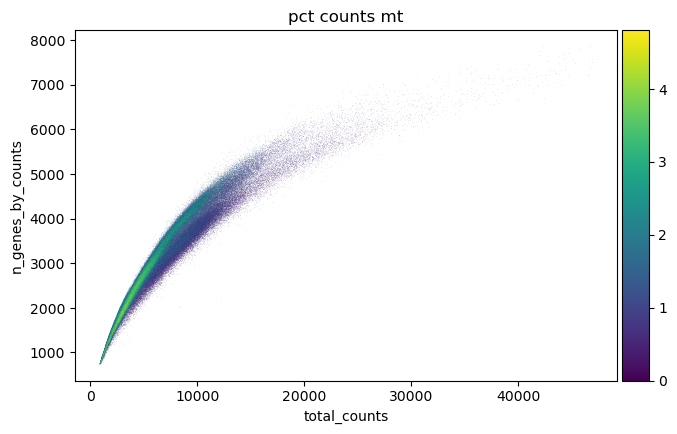

In [28]:
p1 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [29]:
# Filter out genes not detected in at least 20 cells (not informative)

print(f"Total number of genes: {adata.n_vars}")

# Min 20 cells - filters out 0 count genes
sc.pp.filter_genes(adata, min_cells=20)
print(f"Number of genes after cell filter: {adata.n_vars}")

Total number of genes: 18082


Number of genes after cell filter: 15430


In [30]:
# doublet detection

sc.pp.scrublet(adata, batch_key="sample")

In [31]:
# inspect new metadata cols and number of predicted doublets 
display(adata.obs[['doublet_score','predicted_doublet']])
adata.obs['predicted_doublet'].value_counts()

,doublet_score,predicted_doublet
7114ba3cb05111ee829342154c21cb59-0,0.092784,False
7114bb22b05111ee829342154c21cb59-0,0.035918,False
7114bb9ab05111ee829342154c21cb59-0,0.063655,False
7114bc12b05111ee829342154c21cb59-0,0.062298,False
7114bc80b05111ee829342154c21cb59-0,0.195565,False
...,...,...
9e81d7f8bc1211eeb538deb4e32bbba3-22,0.016650,False
9e81d866bc1211eeb538deb4e32bbba3-22,0.025641,False
9e81d94cbc1211eeb538deb4e32bbba3-22,0.033808,False
9e81d9babc1211eeb538deb4e32bbba3-22,0.020533,False


False    452499
True      24806
Name: predicted_doublet, dtype: int64

In [32]:
# per sample predicted doublets
doublets_predicted = (adata.obs.groupby("sample")["predicted_doublet"].sum().astype(int).rename("doublets_predicted"))
doublets_predicted

sample
GSM8464889_fRNA_B155_PB03199-003_labeled       0
GSM8464908_fRNA_B173_PB03287-001_labeled    1501
GSM8464910_fRNA_B151_PB03292-001_labeled    1529
GSM8464911_fRNA_B172_PB03297-001_labeled    2157
GSM8464912_fRNA_B172_PB03303-001_labeled     593
GSM8464914_fRNA_B155_PB03309-001_labeled     955
GSM8464935_fRNA_B172_PB03429-001_labeled    1375
GSM8464958_fRNA_B172_PB03511-001_labeled    3047
GSM8464962_fRNA_B173_PB03518-001_labeled    1251
GSM8464977_fRNA_B155_PB03555-001_labeled    2283
GSM8464981_fRNA_B173_PB03572-001_labeled    1244
GSM8464992_fRNA_B171_PB03598-001_labeled    1602
GSM8464998_fRNA_B173_PB03605-001_labeled       0
GSM8465000_fRNA_B173_PB03610-001_labeled    1750
GSM8465005_fRNA_B171_PB03621-001_labeled       2
GSM8465026_fRNA_B155_PB03692-003_labeled       0
GSM8465046_fRNA_B163_PB03734-003_labeled     607
GSM8465082_fRNA_B173_PB03838-003_labeled     974
GSM8465091_fRNA_B173_PB03858-003_labeled    1727
GSM8465098_fRNA_B155_PB03372-003_labeled       0
GSM8465104_fR

In [33]:
# Filter out doublets
adata = adata[~adata.obs['predicted_doublet']].copy() 

In [34]:
# Save dataset at this stage

ad.settings.allow_write_nullable_strings = True
adata.write("/rds/general/user/ztb25/home/PBMC_datasets/6/QC_rawcounts.h5ad")


In [35]:
# create and export summary table of number of samples/cells per sample before and after filtering

cells_per_sample_after = adata.obs.groupby("sample").size().rename("cells_after_qc")
total_cells_after = adata.n_obs

summary_table = pd.concat(
    [
    cells_per_sample_before, 
    # doublets_predicted,
    cells_per_sample_after
    ],
    axis=1
).astype(int)

# derive removal columns
summary_table["removed_cells"] = (summary_table["cells_before_qc"] - summary_table["cells_after_qc"])
summary_table["pct_removed"] = (
    100 * summary_table["removed_cells"] / summary_table["cells_before_qc"]
).round(2)

summary_table = summary_table.reset_index()  # makes "sample" a normal column

# add diagnosis 
diag_map = adata.obs[["sample"]].drop_duplicates()
summary_table = summary_table.merge(diag_map, on="sample", how="left")

total_row = pd.DataFrame([{
    "sample": "TOTAL",
    "cells_before_qc": summary_table["cells_before_qc"].sum(),
    # "doublets_predicted": summary_table["doublets_predicted"].sum(),
    "cells_after_qc": summary_table["cells_after_qc"].sum(),
    "removed_cells": summary_table["removed_cells"].sum(),
    "pct_removed": round(
        100 * summary_table["removed_cells"].sum() / summary_table["cells_before_qc"].sum(), 2
    )
}])

summary_table = pd.concat([summary_table, total_row], axis=0, ignore_index=True)

#reorder columns
summary_table = summary_table[
    ["sample", "cells_before_qc", "cells_after_qc", "removed_cells", "pct_removed"]
]

summary_table.to_csv("/rds/general/user/ztb25/home/PBMC_datasets/6/QC_summary_table.csv", index=False)
summary_table # fix column names maybe


,sample,cells_before_qc,cells_after_qc,removed_cells,pct_removed
0,GSM8464889_fRNA_B155_PB03199-003_labeled,25199,20118,5081,20.16
1,GSM8464908_fRNA_B173_PB03287-001_labeled,25112,19686,5426,21.61
2,GSM8464910_fRNA_B151_PB03292-001_labeled,23327,19047,4280,18.35
3,GSM8464911_fRNA_B172_PB03297-001_labeled,30206,22883,7323,24.24
4,GSM8464912_fRNA_B172_PB03303-001_labeled,24415,19063,5352,21.92
5,GSM8464914_fRNA_B155_PB03309-001_labeled,22029,16827,5202,23.61
6,GSM8464935_fRNA_B172_PB03429-001_labeled,26291,19933,6358,24.18
7,GSM8464958_fRNA_B172_PB03511-001_labeled,35592,26204,9388,26.38
8,GSM8464962_fRNA_B173_PB03518-001_labeled,22573,18451,4122,18.26
9,GSM8464977_fRNA_B155_PB03555-001_labeled,25600,21584,4016,15.69


In [36]:
##### Normalisation ##### ----------------------------------------------------------------------------------------------------

# # inspect distribution of the raw counts
# p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False)

In [37]:
# Method 1: Shifted logarithm (sc-best practice)

scales_counts = sc.pp.normalize_total(adata, target_sum=None, inplace=False) #changes not made to adata.X
# log1p transform and add to layer
adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True) 

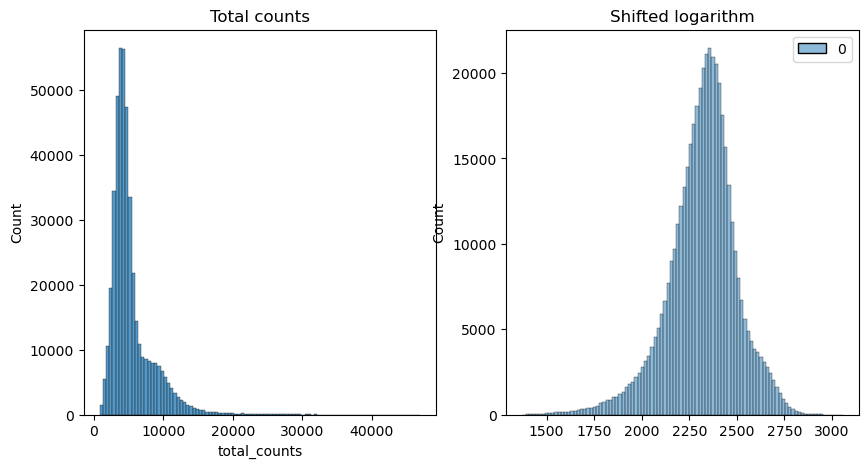

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(adata.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
plt.show()

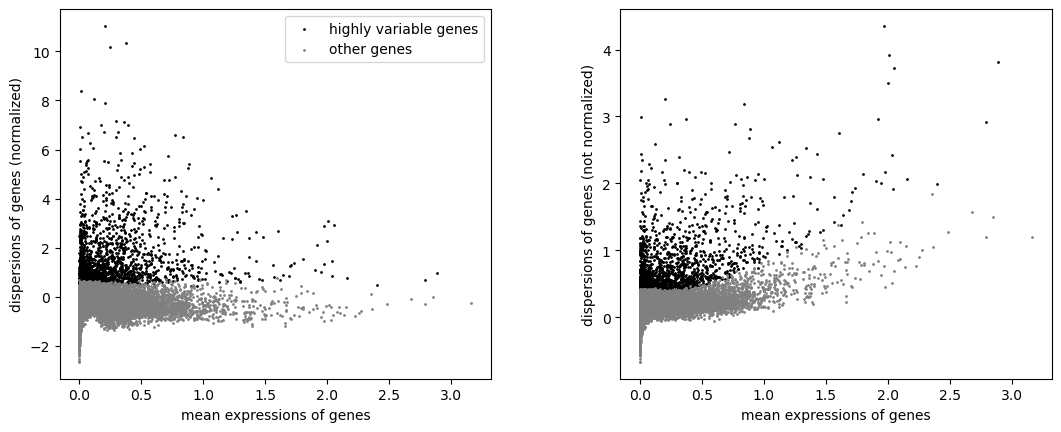

In [39]:
##### Feature Selection ##### ----------------------------------------------------------------------------------------------------
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample", layer = "log1p_norm") # automatically adds columns to adata.var 'highly_variable', 'means', 'dispersions', 'dispersions_norm'. Downstream functions like pca will automatically use only the HVGs if use_highly_variable=True is passed.
sc.pl.highly_variable_genes(adata)

# Mean expression is simply the average expression level of a gene across all cells — how highly expressed it is on average.
# Dispersion is a measure of how much a gene's expression varies across cells, normalized for its mean.

In [40]:
# Save final dataset for integration

adata.write("/rds/general/user/ztb25/home/PBMC_datasets/6/PBMC6_preprocessed.h5ad")